In [137]:
## Importing modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder
import json
import joblib

In [124]:
## Importing datasets
ekg=pd.read_csv("./DataSet/MIT-BIH/100_ekg.csv")
annot=pd.read_csv("./DataSet/MIT-BIH/100_annotations_1.csv")
ekg.head()

,Unnamed: 0,MLII,V5,symbol
0,0,-0.145,-0.065,NaN
1,1,-0.145,-0.065,NaN
2,2,-0.145,-0.065,NaN
3,3,-0.145,-0.065,NaN
4,4,-0.145,-0.065,NaN


In [125]:
print("EKG file of subject 100:")
print(ekg[ekg["symbol"].notna()].head(20))

EKG file of subject 100:
      Unnamed: 0   MLII     V5 symbol
18            18 -0.170 -0.050      +
77            77  0.840  0.210      N
370          370  0.940  0.360      N
662          662  0.885  0.610      N
946          946  0.810  0.545      N
1231        1231  0.820  0.155      N
1515        1515  0.885  0.175      N
1809        1809  0.945  0.595      N
2044        2044  0.845  0.500      A
2402        2402  0.845  0.450      N
2706        2706  0.890  0.275      N
2998        2998  0.925  0.210      N
3282        3282  0.820  0.465      N
3560        3560  0.835 -0.015      N
3862        3862  0.885  0.505      N
4170        4170  0.860  0.470      N
4466        4466  0.795  0.040      N
4764        4764  0.815  0.315      N
5060        5060  0.890  0.455      N
5346        5346  0.820  0.415      N


In [126]:
## Annotation file of subject 100
print("Annotation file of subject 100:")
print(annot.head(20))

Annotation file of subject 100:
    index annotation_symbol
0      18                 +
1      77                 N
2     370                 N
3     662                 N
4     946                 N
5    1231                 N
6    1515                 N
7    1809                 N
8    2044                 A
9    2402                 N
10   2706                 N
11   2998                 N
12   3282                 N
13   3560                 N
14   3862                 N
15   4170                 N
16   4466                 N
17   4764                 N
18   5060                 N
19   5346                 N


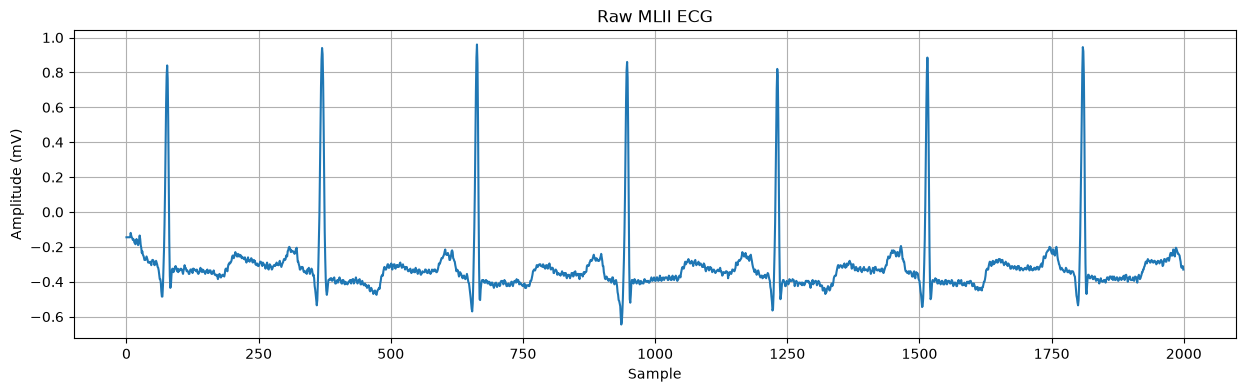

In [127]:
## Plotting the ECG waveform of subject 100
plt.figure(figsize=(15,4))
plt.plot(ekg["Unnamed: 0"][:2000], ekg["MLII"][:2000])
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.title("Raw MLII ECG")
plt.grid(True)
plt.show()

In [128]:
## Extracting MLII (Modified Lead II) for preprocessing
signal=ekg["MLII"]
## Noise removal
fs = 360          # Sampling frequency
lowcut = 0.5
highcut = 40
b, a = butter(
    N=4,
    Wn=[lowcut, highcut],
    btype="band",
    fs=fs
)

filtered_signal = filtfilt(b, a, signal)
ekg["Filtered_MLII"]=filtered_signal
print("Final filtered data:")
print(ekg.head(20))

Final filtered data:
    Unnamed: 0   MLII     V5 symbol  Filtered_MLII
0            0 -0.145 -0.065    NaN       0.033321
1            1 -0.145 -0.065    NaN       0.032719
2            2 -0.145 -0.065    NaN       0.032609
3            3 -0.145 -0.065    NaN       0.033402
4            4 -0.145 -0.065    NaN       0.035322
5            5 -0.145 -0.065    NaN       0.038258
6            6 -0.145 -0.065    NaN       0.041664
7            7 -0.145 -0.065    NaN       0.044614
8            8 -0.120 -0.080    NaN       0.046072
9            9 -0.135 -0.080    NaN       0.045283
10          10 -0.145 -0.085    NaN       0.042089
11          11 -0.150 -0.085    NaN       0.036976
12          12 -0.160 -0.075    NaN       0.030861
13          13 -0.155 -0.070    NaN       0.024754
14          14 -0.160 -0.070    NaN       0.019480
15          15 -0.175 -0.065    NaN       0.015513
16          16 -0.180 -0.055    NaN       0.012925
17          17 -0.185 -0.050    NaN       0.011475
18        

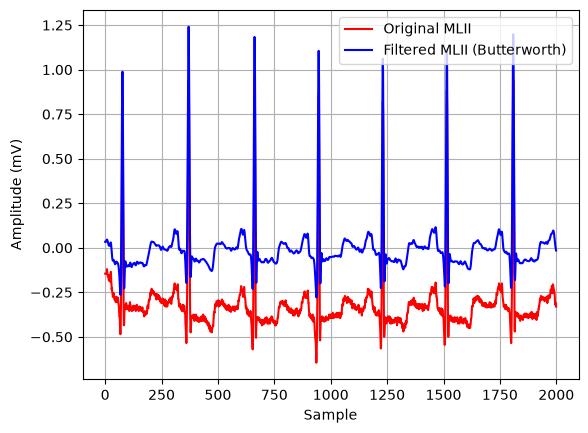

Original mean: -0.3062989769230769
Filtered mean: 1.9946828376439236e-05


In [129]:
## Comparing the nature of filtered MLII and original MLII
plt.plot(ekg["Unnamed: 0"][:2000],ekg["MLII"][:2000],color='red',label="Original MLII")
plt.plot(ekg["Unnamed: 0"][:2000],ekg["Filtered_MLII"][:2000],color='Blue',label="Filtered MLII (Butterworth)")
plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.grid()
plt.legend()
plt.show()
## Printing means
print("Original mean:", ekg["MLII"].mean())
print("Filtered mean:", ekg["Filtered_MLII"].mean())

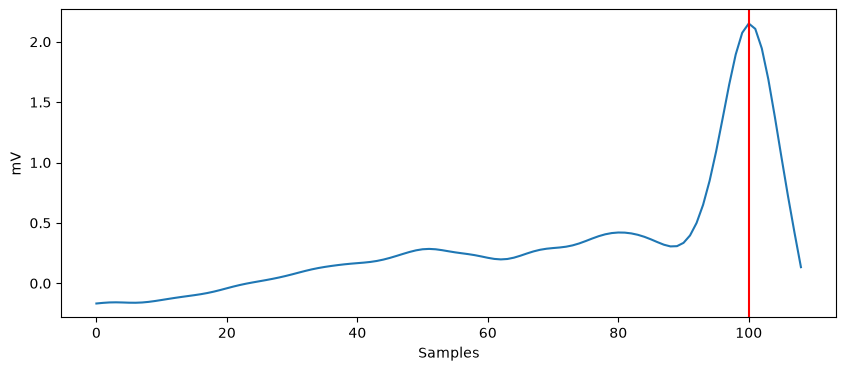

In [130]:
## Obtaining Non-Null annotated values
annotations = ekg[ekg["symbol"].notna()]
for _, row in annotations.iterrows():

    r_peak = int(row["Unnamed: 0"])

    beat = filtered_signal[r_peak-100:r_peak+150]

## Showing the final windows centered around the labelled values
plt.figure(figsize=(10,4))
plt.plot(beat)
plt.axvline(100, color="red")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.show()

In [131]:
## Converting values to annotations

label = []
features = []

valid_symbols = ["N", "A", "V", "F", "L", "R"]

annotations = ekg[ekg["symbol"].isin(valid_symbols)]

for _, row in annotations.iterrows():

    r_peak = int(row["Unnamed: 0"])

    # avoid boundary problems
    if r_peak < 100 or r_peak + 150 >= len(filtered_signal):
        continue

    beat = filtered_signal[r_peak-100:r_peak+150]

    features.append(beat)
    label.append(row["symbol"])

In [132]:
## Converting x,y to np arrays

x = np.array(features)
y = np.array(label)
## View the 10 heart beats
print(x[:10],y[:10])

[[-0.01206271 -0.01187019 -0.01232292 ...  0.03146078  0.03174057
   0.03049134]
 [-0.00764133 -0.00449362 -0.00224039 ... -0.00220701 -0.00247043
  -0.00201568]
 [-0.01708789 -0.01565799 -0.01470599 ...  0.02109111  0.01656689
   0.01169944]
 ...
 [-0.01505915 -0.01594297 -0.01533467 ...  0.03493711  0.03578173
   0.03581829]
 [-0.00424834 -0.00308809 -0.0026498  ...  0.02714747  0.02598553
   0.02446223]
 [-0.01443858 -0.01356217 -0.01300669 ...  0.01748514  0.01461687
   0.01037657]] ['N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N']


In [133]:
## Encoding the value labels
label_Encoder = LabelEncoder()
label_Encoder.fit(valid_symbols)
print(label_Encoder.classes_)

['A' 'F' 'L' 'N' 'R' 'V']


In [134]:
## Obtain patient Metadata from json
with open("DataSet/MIT-BIH/100_ekg.json", "r") as f:
    metadata = json.load(f)
patient_info = metadata["comments"][0]
parts = patient_info.split()

## Encode the sex
sex_encoder = LabelEncoder()
sex_encoder.fit(["M", "F"])
print(sex_encoder.classes_)
age = int(parts[0])
sex = parts[1]
sex=sex_encoder.transform([sex])[0]
print(age,sex)

['F' 'M']
69 1


In [135]:
## Creating Preprocessed Dataset
## Append the features throughout the file
age_column = np.full((len(x), 1), age)
sex_column = np.full((len(x), 1), sex)

X_final =np.hstack(
    (
        x,
        age_column,
        sex_column
    )
)
columns = [
    f"ecg_{i}" for i in range(x.shape[1])
]
columns += [
    "age",
    "sex",
    "label"
]
y_encoded=label_Encoder.transform(y)
df_processed = pd.DataFrame(
    np.column_stack((X_final, y_encoded)),
    columns=columns
)
df_processed["record"]=100
# print(df_processed)
# print(df_processed.shape)
print(df_processed["label"])
print(np.unique(y, return_counts=True))

0       3.0
1       3.0
2       3.0
3       3.0
4       3.0
       ... 
2266    3.0
2267    3.0
2268    3.0
2269    3.0
2270    3.0
Name: label, Length: 2271, dtype: float64
(array(['A', 'N', 'V'], dtype='<U1'), array([  33, 2237,    1]))


In [136]:
## Creating Preprocessed dataset
df_processed["label"] = df_processed["label"].astype(int)
df_processed["sex"] = df_processed["sex"].astype(int)
df_processed["age"] = df_processed["age"].astype(int)

df_processed.to_csv(
    "MITBIH_preprocessed_100.csv",
    index=False
)

directory = "MIT_Preprocessed_Datasets"

# Create directory if it does not exist
os.makedirs(directory, exist_ok=True)

# File path inside the directory
file_path = os.path.join(directory, "MITBIH_preprocessed_100.csv")

# Save dataframe
df_processed.to_csv(file_path, index=False)


In [142]:
# Create directory
os.makedirs(
    "preprocessing_objects",
    exist_ok=True
)
# Save label encoder
joblib.dump(
    label_Encoder,
    "preprocessing_objects/label_encoder.joblib"
)
# Save sex encoder
joblib.dump(
    sex_encoder,
    "preprocessing_objects/sex_encoder.joblib"
)
# Save filter coefficients
filter_params = {
    "b": b,
    "a": a,
    "fs": fs,
    "order": 4,
    "lowcut": lowcut,
    "highcut": highcut
}
joblib.dump(
    filter_params,
    "preprocessing_objects/butterworth_filter.joblib"
)
valid_leads = [
    "MLII",
    "V5",
    "V2",
    "V3"
    "V1",
    "V4"
]
lead_encoder = LabelEncoder()
lead_encoder.fit(valid_leads)
print(lead_encoder.classes_)
joblib.dump(lead_encoder,"preprocessing_objects/lead_encoder.joblib")
print("Preprocessing objects saved successfully")

['MLII' 'V2' 'V3V1' 'V4' 'V5']
Preprocessing objects saved successfully
